<a href="https://colab.research.google.com/github/chtmnPlfy/Coffee-in-Trend/blob/main/thailand_export_import_trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab — skipping drive mount.")

Mounted at /content/drive


In [5]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_excel("/content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend/coffee_trade_merged_2022-2024.xlsx")

In [11]:
df.describe()

,Exports (USD) 2022,Exports Share (%) 2022,Exports ECI 2022,Imports (USD) 2022,Imports Share (%) 2022,Imports ECI 2022,Exports (USD) 2023,Exports Share (%) 2023,Exports ECI 2023,Imports (USD) 2023,Imports Share (%) 2023,Imports ECI 2023,Exports (USD) 2024,Exports Share (%) 2024,Exports ECI 2024,Imports (USD) 2024,Imports Share (%) 2024,Imports ECI 2024
count,1.980000e+02,198.000000,129.000000,2.210000e+02,221.000000,131.000000,2.000000e+02,200.000000,128.000000,2.250000e+02,225.000000,131.000000,1.950000e+02,195.000000,126.000000,2.230000e+02,223.000000,130.000000
mean,2.347693e+08,0.505020,0.023465,2.103363e+08,0.452425,0.000015,2.146112e+08,0.499985,0.018305,1.907655e+08,0.444418,-0.000015,2.596992e+08,0.512795,0.033849,2.270912e+08,0.448448,0.000038
std,8.637078e+08,1.858076,0.986722,7.886469e+08,1.696566,1.000011,7.730380e+08,1.800996,1.004156,6.720128e+08,1.565657,0.999983,1.034817e+09,2.043423,0.990733,8.031430e+08,1.585912,0.999990
min,6.000000e+00,0.000000,-2.046000,1.481000e+03,0.000000,-2.118000,4.000000e+00,0.000000,-2.355000,1.600000e+01,0.000000,-2.355000,1.200000e+01,0.000000,-2.513000,5.720000e+02,0.000000,-2.513000
25%,2.951200e+04,0.000000,-0.614000,4.896700e+05,0.001000,-0.680500,6.183775e+04,0.000000,-0.720250,5.665100e+05,0.001000,-0.733500,4.271900e+04,0.000000,-0.693250,3.495385e+05,0.001000,-0.759000
50%,1.831031e+06,0.004000,0.005000,3.646160e+06,0.008000,-0.002000,2.437040e+06,0.006000,-0.051500,4.464455e+06,0.010000,-0.070000,4.106371e+06,0.008000,-0.020000,3.705675e+06,0.007000,-0.040500
75%,3.890626e+07,0.083750,0.802000,1.029342e+08,0.221000,0.799000,4.110445e+07,0.096000,0.798250,1.018851e+08,0.237000,0.791500,4.216236e+07,0.083500,0.802750,1.149444e+08,0.227000,0.769750
max,9.095132e+09,19.566000,1.995000,8.935825e+09,19.223000,1.995000,7.878452e+09,18.355000,2.106000,7.560545e+09,17.615000,2.106000,1.174371e+10,23.190000,2.085000,8.787515e+09,17.352000,2.085000


In [13]:
thailand = df[df["Country"] == "Thailand"]
print(thailand.T)
print("\nNaN check:")
print(thailand.isna().sum())

                                201
Country ID                      THA
Country                    Thailand
Exports (USD) 2022        6449490.0
Exports Share (%) 2022        0.014
Exports ECI 2022              0.802
Imports (USD) 2022      160910758.0
Imports Share (%) 2022        0.346
Imports ECI 2022              0.802
Exports (USD) 2023        6473521.0
Exports Share (%) 2023        0.015
Exports ECI 2023              0.817
Imports (USD) 2023      198038274.0
Imports Share (%) 2023        0.461
Imports ECI 2023              0.817
Exports (USD) 2024       10184716.0
Exports Share (%) 2024         0.02
Exports ECI 2024              0.813
Imports (USD) 2024      277517412.0
Imports Share (%) 2024        0.548
Imports ECI 2024              0.813

NaN check:
Country ID                0
Country                   0
Exports (USD) 2022        0
Exports Share (%) 2022    0
Exports ECI 2022          0
Imports (USD) 2022        0
Imports Share (%) 2022    0
Imports ECI 2022          0
Exports 

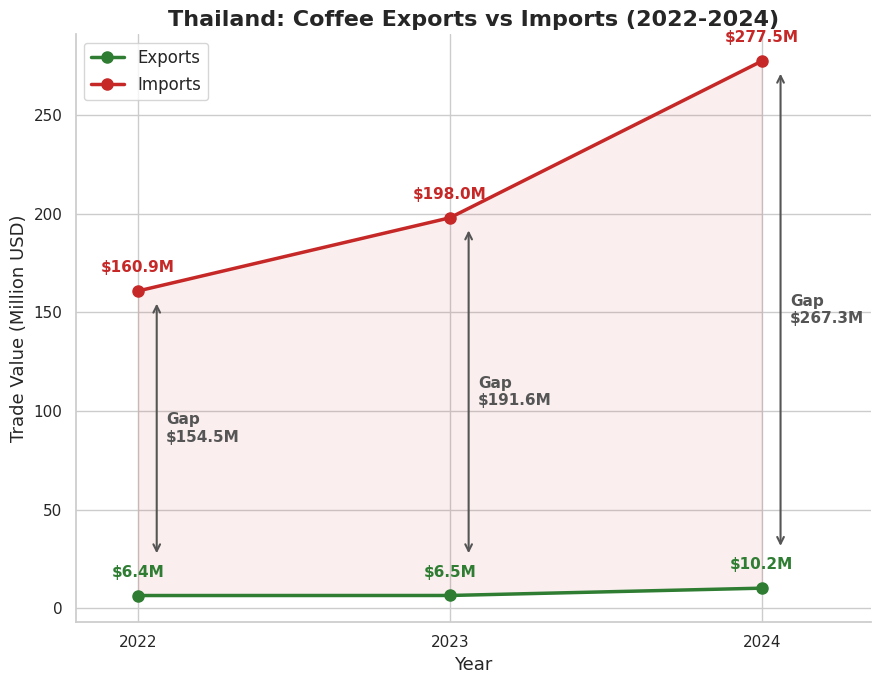

   Year  Exports (Million USD)  Imports (Million USD)  Gap (Million USD)
0  2022               6.449490             160.910758         154.461268
1  2023               6.473521             198.038274         191.564753
2  2024              10.184716             277.517412         267.332696


In [20]:
thailand = df[df["Country"] == "Thailand"]

# --- 3. Reshape from wide (year-suffixed columns) to long (Year, Exports, Imports) ---
years = [2022, 2023, 2024]
plot_df = pd.DataFrame({
    "Year": years,
    "Exports (Million USD)": [thailand[f"Exports (USD) {y}"].values[0] / 1e6 for y in years],
    "Imports (Million USD)": [thailand[f"Imports (USD) {y}"].values[0] / 1e6 for y in years],
})

# --- 4. Plot: line chart (best fit for a short time trend of 2 series) ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(plot_df["Year"], plot_df["Exports (Million USD)"], marker="o",
        linewidth=2.5, markersize=8, color="#2E7D32", label="Exports")
ax.plot(plot_df["Year"], plot_df["Imports (Million USD)"], marker="o",
        linewidth=2.5, markersize=8, color="#C62828", label="Imports")
ax.fill_between(plot_df["Year"], plot_df["Exports (Million USD)"],
                 plot_df["Imports (Million USD)"], color="#C62828", alpha=0.08)

# --- 5. Label each point with its value ---
for _, row in plot_df.iterrows():
    ax.text(row["Year"], row["Exports (Million USD)"] + 8,
            f"${row['Exports (Million USD)']:.1f}M",
            ha="center", va="bottom", fontsize=11, fontweight="bold", color="#2E7D32")
    ax.text(row["Year"], row["Imports (Million USD)"] + 8,
            f"${row['Imports (Million USD)']:.1f}M",
            ha="center", va="bottom", fontsize=11, fontweight="bold", color="#C62828")

# --- 6. Identify the gap (Imports - Exports) for each year ---
plot_df["Gap (Million USD)"] = plot_df["Imports (Million USD)"] - plot_df["Exports (Million USD)"]

for _, row in plot_df.iterrows():
    x = row["Year"] + 0.06                       # shift right so the arrow doesn't sit on the gridline
    y_low = row["Exports (Million USD)"] + 20    # start above the green export label
    y_high = row["Imports (Million USD)"] - 5    # stop just below the import point
    ax.annotate("", xy=(x, y_high), xytext=(x, y_low),
                arrowprops=dict(arrowstyle="<->", color="#555555", lw=1.5))
    ax.text(x + 0.03, (y_low + y_high) / 2,
            f"Gap\n${row['Gap (Million USD)']:.1f}M",
            ha="left", va="center", fontsize=11, fontweight="bold", color="#555555")

ax.set_xlim(2021.8, 2024.35)                     # room on the right for the 2024 gap label

ax.set_title("Thailand: Coffee Exports vs Imports (2022-2024)", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Trade Value (Million USD)", fontsize=13)
ax.set_xticks(years)
ax.legend(fontsize=12)
sns.despine()

plt.tight_layout()
plt.savefig("thailand_export_import_trend.png", dpi=120, bbox_inches="tight", pad_inches=0.3)
plt.show()

print(plot_df)

Latest Consumption

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Year     Variable        kg
0  2023   Production  45000000
1  2024   Production  42000000
2  2023  Consumption  52800000
3  2024  Consumption  55500000


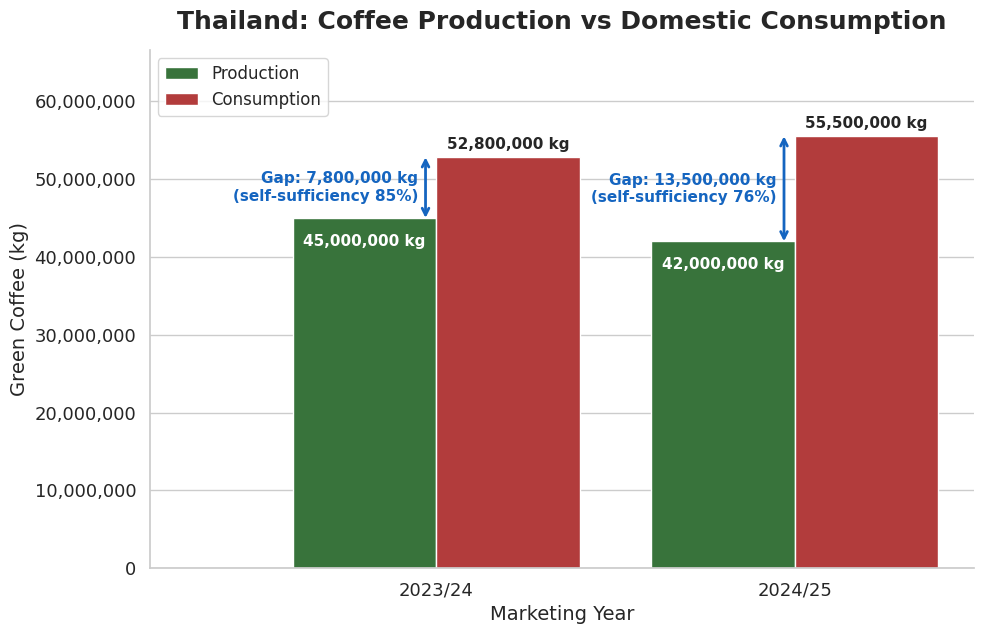

In [22]:
"""
Thailand: Coffee Exports vs Imports (2018-2024)
Same design as the production-vs-consumption chart: grouped bars + gap bracket
Reads directly from: coffee_trade_merged_2018-2024.xlsx
Libraries: pandas (reshaping) + matplotlib/seaborn (grouped bar chart)
"""

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0. Mount Google Drive (Google Colab environment) ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab — skipping drive mount.")

BASE_DIR = "/content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend"


def locate_file(filename, base_dir=BASE_DIR):
    exact = os.path.join(base_dir, filename)
    if os.path.exists(exact):
        return exact
    matches = glob.glob(f"/content/drive/MyDrive/**/{filename}", recursive=True)
    return matches[0] if matches else filename


# --- 1. Read data and filter to Thailand ---
df = pd.read_excel(locate_file("coffee_trade_merged_2018-2024.xlsx"))
thailand = df[df["Country"] == "Thailand"]

# --- 2. Reshape wide (year-suffixed columns) -> long (Year, Variable, Million USD) ---
years = list(range(2018, 2025))
rows = []
for y in years:
    rows.append({"Year": y, "Variable": "Exports",
                 "Million USD": thailand[f"Exports (USD) {y}"].values[0] / 1e6})
    rows.append({"Year": y, "Variable": "Imports",
                 "Million USD": thailand[f"Imports (USD) {y}"].values[0] / 1e6})
plot_df = pd.DataFrame(rows)
wide = plot_df.pivot(index="Year", columns="Variable", values="Million USD")
wide["Gap"] = wide["Imports"] - wide["Exports"]
print(wide.round(1))

# --- 3. Plot: grouped bars ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 7.5))

sns.barplot(data=plot_df, x="Year", y="Million USD", hue="Variable",
            palette={"Exports": "#2E7D32", "Imports": "#C62828"}, ax=ax)

# Value labels on top of each bar
exp_container, imp_container = ax.containers
ax.bar_label(exp_container, labels=[f"${v:.1f}M" for v in exp_container.datavalues],
             padding=3, fontsize=10, fontweight="bold", color="#2E7D32")
ax.bar_label(imp_container, labels=[f"${v:.1f}M" for v in imp_container.datavalues],
             padding=3, fontsize=10, fontweight="bold", color="#C62828")

# Gap (imports - exports): bracket at the seam between the two bars
for i, (year, r) in enumerate(wide.iterrows()):
    x = i - 0.03                                   # just left of where the two bars meet
    y_low = r["Exports"] + wide["Imports"].max() * 0.05   # start above the export label
    ax.annotate("", xy=(x, r["Imports"]), xytext=(x, y_low),
                arrowprops=dict(arrowstyle="<->", color="#1565C0", lw=1.8,
                                shrinkA=0, shrinkB=0))
    ax.text(x - 0.03, (y_low + r["Imports"]) / 2, f"Gap\n${r['Gap']:.1f}M",
            ha="right", va="center", fontsize=10, color="#1565C0", fontweight="bold")

ax.set_ylim(0, wide["Imports"].max() * 1.12)
ax.set_title("Thailand: Coffee Exports vs Imports (2018-2024)",
             fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Trade Value (Million USD)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(title="", fontsize=12, loc="upper left")
sns.despine()

plt.tight_layout()
plt.savefig("thailand_exports_vs_imports_2018_2024.png", dpi=120,
            bbox_inches="tight", pad_inches=0.3)
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File found: /content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend/coffee_trade_merged_2018-2024.xlsx


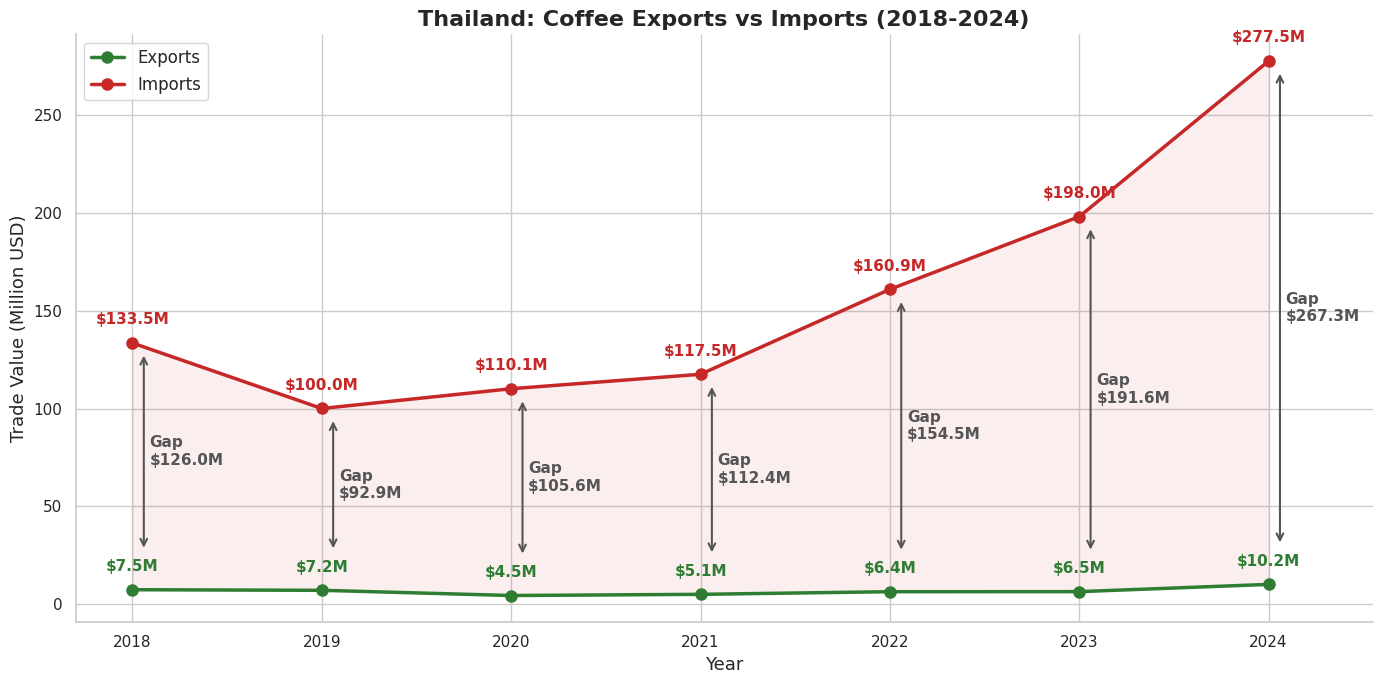

   Year  Exports (Million USD)  Imports (Million USD)  Gap (Million USD)
0  2018               7.464636             133.486975         126.022339
1  2019               7.159845             100.033718          92.873873
2  2020               4.494671             110.134079         105.639408
3  2021               5.105988             117.524311         112.418323
4  2022               6.449490             160.910758         154.461268
5  2023               6.473521             198.038274         191.564753
6  2024              10.184716             277.517412         267.332696


In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0. Mount Google Drive (Google Colab environment) ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab — skipping drive mount.")

BASE_DIR = "/content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend"


def locate_file(filename, base_dir=BASE_DIR):
    exact = os.path.join(base_dir, filename)
    if os.path.exists(exact):
        print(f"File found: {exact}")
        return exact
    print(f"File not found at exact path: {exact}")
    matches = glob.glob(f"/content/drive/MyDrive/**/{filename}", recursive=True)
    if matches:
        print(f"Found instead at: {matches[0]}")
        return matches[0]
    print(f"Falling back to relative path: {filename}")
    return filename


data_path = locate_file("coffee_trade_merged_2018-2024.xlsx")

# --- 1. Read data directly from file ---
df = pd.read_excel(data_path)

# --- 2. Filter to Thailand only ---
thailand = df[df["Country"] == "Thailand"]

# --- 3. Reshape from wide (year-suffixed columns) to long (Year, Exports, Imports) ---
years = list(range(2018, 2025))
plot_df = pd.DataFrame({
    "Year": years,
    "Exports (Million USD)": [thailand[f"Exports (USD) {y}"].values[0] / 1e6 for y in years],
    "Imports (Million USD)": [thailand[f"Imports (USD) {y}"].values[0] / 1e6 for y in years],
})

# --- 4. Plot: line chart (best fit for a short time trend of 2 series) ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(plot_df["Year"], plot_df["Exports (Million USD)"], marker="o",
        linewidth=2.5, markersize=8, color="#2E7D32", label="Exports")
ax.plot(plot_df["Year"], plot_df["Imports (Million USD)"], marker="o",
        linewidth=2.5, markersize=8, color="#C62828", label="Imports")
ax.fill_between(plot_df["Year"], plot_df["Exports (Million USD)"],
                 plot_df["Imports (Million USD)"], color="#C62828", alpha=0.08)

# --- 5. Label each point with its value ---
for _, row in plot_df.iterrows():
    ax.text(row["Year"], row["Exports (Million USD)"] + 8,
            f"${row['Exports (Million USD)']:.1f}M",
            ha="center", va="bottom", fontsize=11, fontweight="bold", color="#2E7D32")
    ax.text(row["Year"], row["Imports (Million USD)"] + 8,
            f"${row['Imports (Million USD)']:.1f}M",
            ha="center", va="bottom", fontsize=11, fontweight="bold", color="#C62828")

# --- 6. Identify the gap (Imports - Exports) for each year ---
plot_df["Gap (Million USD)"] = plot_df["Imports (Million USD)"] - plot_df["Exports (Million USD)"]

for _, row in plot_df.iterrows():
    x = row["Year"] + 0.06                       # shift right so the arrow doesn't sit on the gridline
    y_low = row["Exports (Million USD)"] + 20    # start above the green export label
    y_high = row["Imports (Million USD)"] - 5    # stop just below the import point
    ax.annotate("", xy=(x, y_high), xytext=(x, y_low),
                arrowprops=dict(arrowstyle="<->", color="#555555", lw=1.5))
    ax.text(x + 0.03, (y_low + y_high) / 2,
            f"Gap\n${row['Gap (Million USD)']:.1f}M",
            ha="left", va="center", fontsize=11, fontweight="bold", color="#555555")

ax.set_xlim(2017.7, 2024.55)                     # room on the right for the 2024 gap label

ax.set_title("Thailand: Coffee Exports vs Imports (2018-2024)", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Trade Value (Million USD)", fontsize=13)
ax.set_xticks(years)
ax.legend(fontsize=12)
sns.despine()

plt.tight_layout()
plt.savefig("thailand_export_import_trend_2018_2024.png", dpi=120, bbox_inches="tight", pad_inches=0.3)
plt.show()

print(plot_df)